## Contents
1. Install dependencies and import libraries
2. Load YOLOv8 model via `kagglehub`
3. Run inference on a few sample images
4. Process entire dataset
5. Visualize cropped plates
6. Export ZIP for further use

In [ ]:
# Cell 1: Install and import libraries

# Core libraries
import os
import cv2
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from PIL import Image

# YOLO and KaggleHub
import kagglehub
from ultralytics import YOLO

C:\Users\Korisnik\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Korisnik\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Cell 2: Download model and dataset

# Download model
try:
    model_path = kagglehub.model_download("harshitsingh09/yolov8-license-plate-detector/pyTorch/default")
    model_file = os.path.join(model_path, "best.pt")
    assert os.path.exists(model_file), "Model file not found after download."
    print("Model loaded from:", model_file)
except Exception as e:
    raise RuntimeError(f"Failed to download/load model: {e}")

# Download dataset
try:
    dataset_path = kagglehub.dataset_download("harshitsingh09/license-plate-detection-dataset-anpr-yolo-format")
    val_glob_path = os.path.join(dataset_path, "YOLO_dataset/images/val", "*.png")
    val_images = glob(val_glob_path)
    assert len(val_images) > 0, "No validation images found in dataset."
    print("Dataset loaded from:", dataset_path)
except Exception as e:
    raise RuntimeError(f"Failed to download/load dataset: {e}")

# Load YOLOv8 model
model = YOLO(model_file)

# Sample 5 random images from validation set
random.seed(2003)
image_paths = random.sample(val_images, min(5, len(val_images)))

100%|██████████| 5.85M/5.85M [00:02<00:00, 2.22MB/s]


✅ Model loaded from: C:\Users\Korisnik\.cache\kagglehub\models\harshitsingh09\yolov8-license-plate-detector\pyTorch\default\1\best.pt


100%|██████████| 241M/241M [01:14<00:00, 3.40MB/s] 

Extracting files...


✅ Dataset loaded from: C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3



image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\val\Cars74.png: 448x640 1 number_plate, 827.8ms
Speed: 85.4ms preprocess, 827.8ms inference, 36.0ms postprocess per image at shape (1, 3, 448, 640)


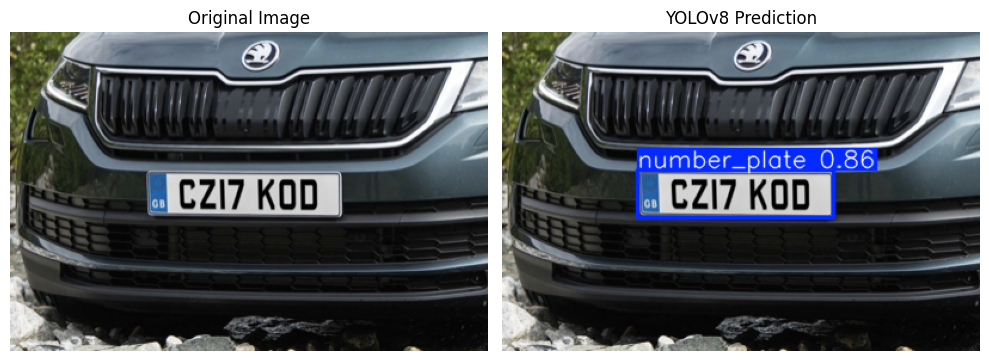


image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\val\Cars160.png: 384x640 1 number_plate, 875.7ms
Speed: 8.4ms preprocess, 875.7ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)


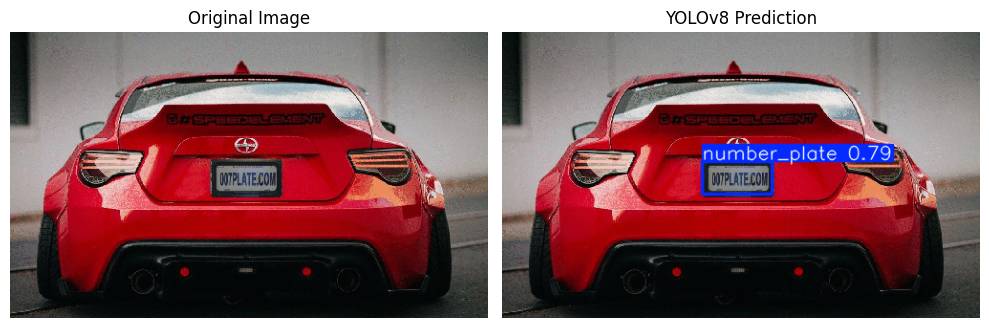


image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\val\Cars119.png: 416x640 3 number_plates, 1120.8ms
Speed: 11.5ms preprocess, 1120.8ms inference, 5.7ms postprocess per image at shape (1, 3, 416, 640)


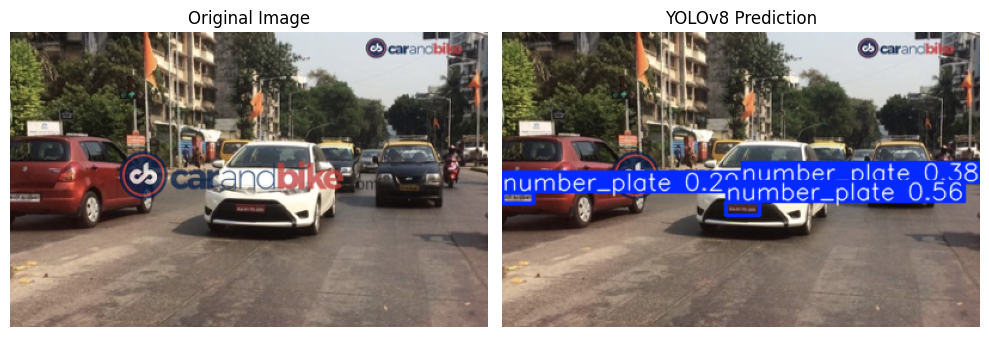


image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\val\Cars235.png: 384x640 1 number_plate, 941.4ms
Speed: 12.1ms preprocess, 941.4ms inference, 3.6ms postprocess per image at shape (1, 3, 384, 640)


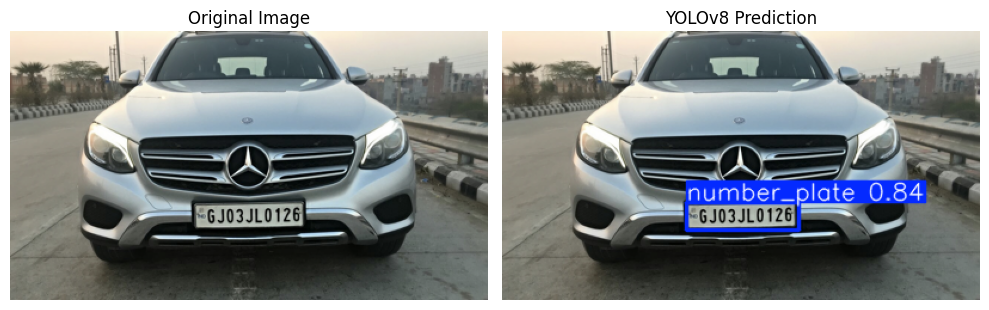


image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\val\Cars219.png: 480x640 1 number_plate, 835.2ms
Speed: 13.8ms preprocess, 835.2ms inference, 11.7ms postprocess per image at shape (1, 3, 480, 640)


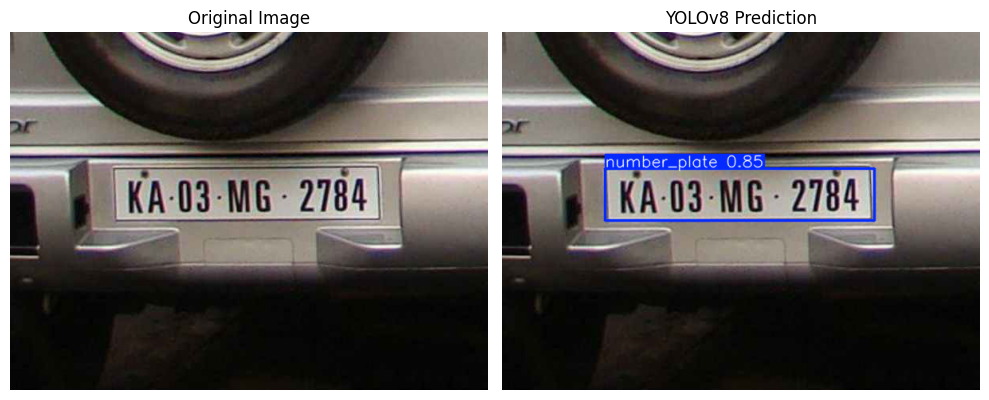

In [ ]:
# Cell 3: Run inference and show original vs predicted images side-by-side

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        print(f"Skipping unreadable image: {img_path}")
        continue

    # Run inference
    try:
        results = model(img_path)
        if not results or not hasattr(results[0], 'plot'):
            print(f"No predictions for {img_path}")
            continue

        # Get image with drawn boxes
        result_img = results[0].plot()  # Returns BGR numpy array with boxes drawn

    except Exception as e:
        print(f"Inference failed on {img_path}: {e}")
        continue

    # Display both images side-by-side using matplotlib
    plt.figure(figsize=(10, 5))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    # Predicted result image
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title("YOLOv8 Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 4: Inference on full dataset and save cropped license plates

# Reuse model and dataset paths
model = YOLO(f"{model_path}/best.pt")

image_dirs = [
    os.path.join(dataset_path, "YOLO_dataset/images/train"),
    os.path.join(dataset_path, "YOLO_dataset/images/val")
]

# Output directory for cropped plates
output_dir = "/kaggle/working/numberplates"
os.makedirs(output_dir, exist_ok=True)

# Collect image paths with valid extensions
image_paths = []
for d in image_dirs:
    image_paths += glob(os.path.join(d, "*.png"))
    image_paths += glob(os.path.join(d, "*.jpeg"))
    image_paths += glob(os.path.join(d, "*.jpg"))

# Counters
crop_count = 0
skipped_images = []

# Process images
for img_path in tqdm(image_paths, desc="Processing images"):
    try:
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError("Unreadable image")

        results = model(img_path)
        boxes = getattr(results[0], "boxes", None)

        if not boxes or len(boxes) == 0:
            skipped_images.append(os.path.basename(img_path))
            continue

        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            h, w = img.shape[:2]

            # Clamp coordinates to image boundaries
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            cropped = img[y1:y2, x1:x2]
            if cropped.size == 0:
                continue

            # Save cropped plate
            base = os.path.splitext(os.path.basename(img_path))[0]
            crop_path = os.path.join(output_dir, f"{base}_{i}.png")
            cv2.imwrite(crop_path, cropped)
            crop_count += 1

    except Exception as e:
        print(f"Failed to process {img_path}: {e}")
        skipped_images.append(os.path.basename(img_path))

# Summary
print(f"\nProcessed {len(image_paths)} images from train/val.")
print(f"Saved {crop_count} cropped license plate(s) to: {output_dir}")
print(f"Skipped {len(skipped_images)} image(s) due to issues or no detections.")

Processing images:   0%|          | 0/658 [00:00<?, ?it/s]


image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\train\Cars0.png: 352x640 1 number_plate, 1646.5ms
Speed: 12.4ms preprocess, 1646.5ms inference, 3.0ms postprocess per image at shape (1, 3, 352, 640)


Processing images:   0%|          | 1/658 [00:01<19:24,  1.77s/it]


image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\train\Cars1.png: 416x640 1 number_plate, 1182.6ms
Speed: 30.0ms preprocess, 1182.6ms inference, 3.4ms postprocess per image at shape (1, 3, 416, 640)


Processing images:   0%|          | 2/658 [00:03<16:52,  1.54s/it]

...


image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\val\N91.jpeg: 448x640 1 number_plate, 455.6ms
Speed: 7.1ms preprocess, 455.6ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)


Processing images: 100%|█████████▉| 657/658 [07:35<00:00,  1.67it/s]


image 1/1 C:\Users\Korisnik\.cache\kagglehub\datasets\harshitsingh09\license-plate-detection-dataset-anpr-yolo-format\versions\3\YOLO_dataset\images\val\N92.jpeg: 512x640 1 number_plate, 500.3ms
Speed: 8.2ms preprocess, 500.3ms inference, 3.0ms postprocess per image at shape (1, 3, 512, 640)


Processing images: 100%|██████████| 658/658 [07:36<00:00,  1.44it/s]


✅ Processed 658 images from train/val.
📦 Saved 734 cropped license plate(s) to: /kaggle/working/numberplates
❌ Skipped 2 image(s) due to issues or no detections.


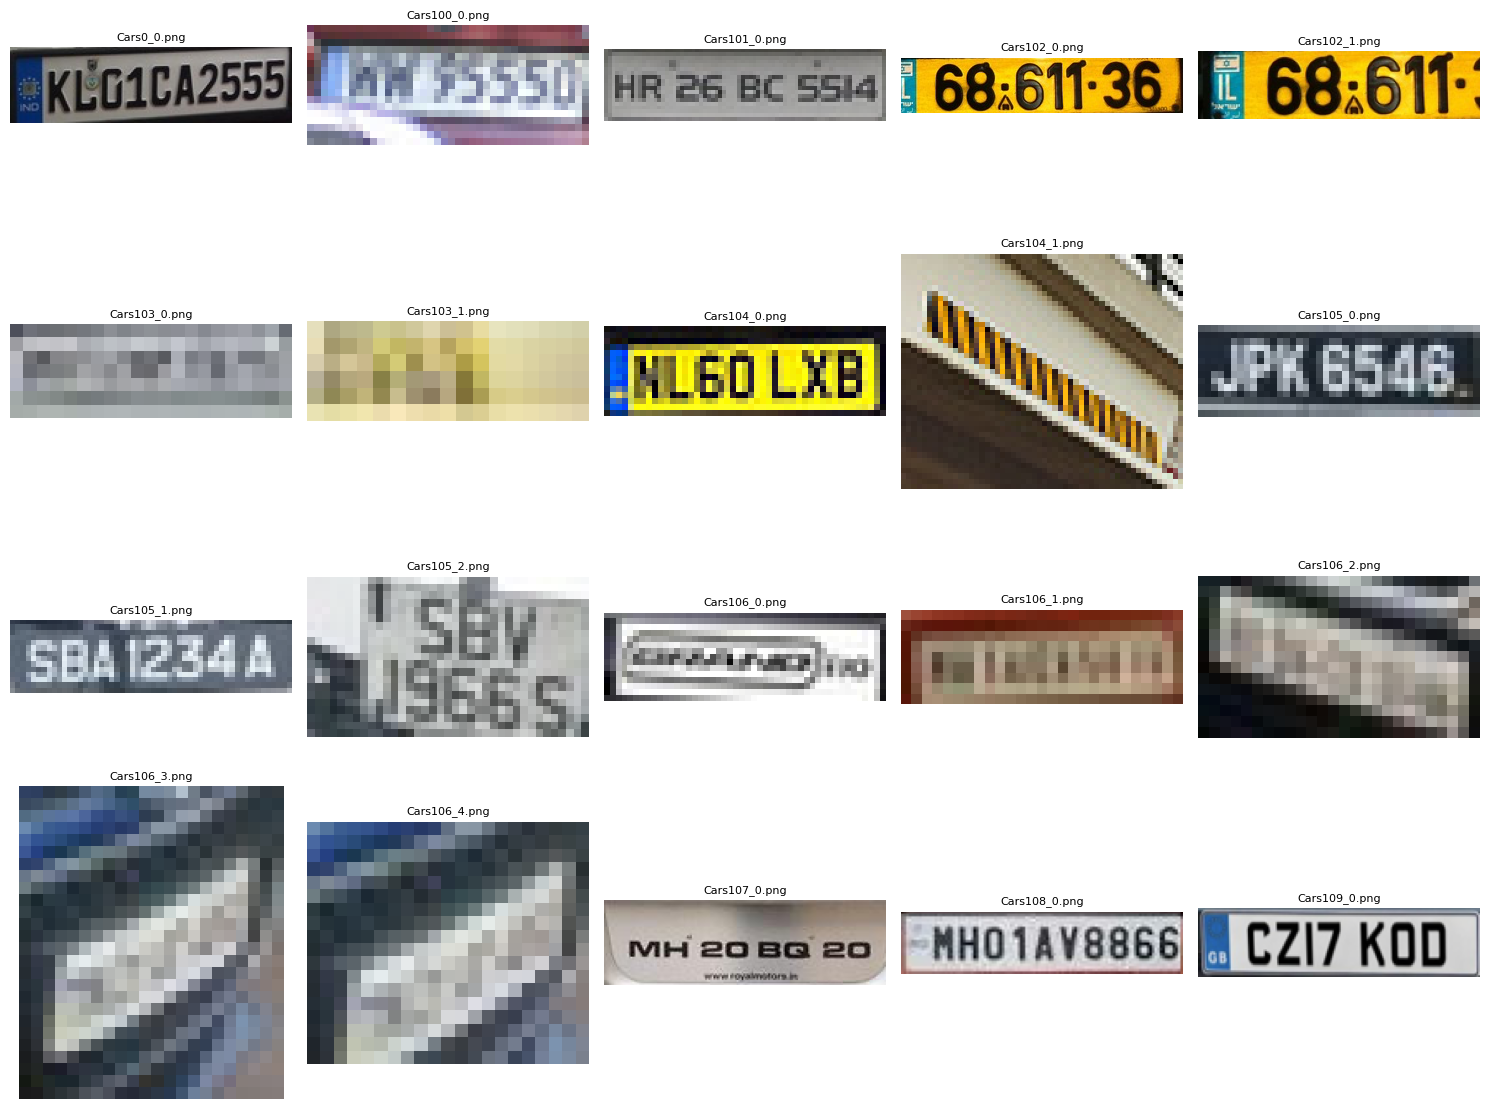

In [ ]:
# Cell 5: Display up to 20 cropped license plates in a grid

# Load cropped images
cropped_imgs = sorted(glob(os.path.join(output_dir, "*.png")))[:20]

if not cropped_imgs:
    print("No cropped images found to display.")
else:
    cols = 5
    rows = (len(cropped_imgs) + cols - 1) // cols
    plt.figure(figsize=(15, 3 * rows))

    for idx, path in enumerate(cropped_imgs):
        img = cv2.imread(path)
        if img is None:
            print(f"Skipping unreadable image: {path}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img_rgb)
        plt.title(os.path.basename(path), fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 6: Create ZIP archive of cropped license plates

# Define source folder and output zip path
source_dir = output_dir
zip_path = "/kaggle/working/numberplates_dataset.zip"

# Create ZIP archive
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(source_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, start=source_dir)
            zipf.write(file_path, arcname)

print(f"Zipped {len(os.listdir(source_dir))} cropped image(s) to: {zip_path}")